# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [5]:
# Load the libraries as required.

In [6]:
# Load data
import pandas as pd

columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]

fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
fires_dt.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [7]:
import pandas as pd

# Define column names exactly as per dataset
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]

# Load data with the correct column names
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)

# Separate features and target
X = fires_dt.drop('area', axis=1)  # all columns except 'area'
y = fires_dt['area']               # target variable

# Check
print(X.head())
print(y.head())


   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# List numeric and categorical features based on your dataset
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
categorical_features = ['month', 'day']

# Define the preproc1 transformer
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),       # Scale numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encode categoricals
    ]
)


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [37]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Define the named transformation function
def log1p_transform(x):
    return np.log1p(x)

# Define columns
numeric_features = ['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(log1p_transform)),  # ✅ Named function
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Column transformer
preproc2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [10]:
# Pipeline A = preproc1 + baseline
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Load data and prepare X, y
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Define numeric and categorical columns
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
categorical_features = ['month', 'day']

# Define preproc1: scale numeric, one-hot encode categorical
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Create pipeline with preproc1 and Lasso regressor
pipeline_a = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Lasso(random_state=42))
])

# Define hyperparameter grid for Lasso alpha
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]
}

# Setup grid search with 5-fold CV, scoring RMSE (negated)
grid_search = GridSearchCV(
    pipeline_a,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X, y)

# Print best alpha and best CV RMSE score
print("Best alpha:", grid_search.best_params_['regressor__alpha'])
print("Best CV RMSE:", -grid_search.best_score_)


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.387e+03, tolerance: 2.077e+02
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.134e+03, tolerance: 2.069e+02
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

Best alpha: 10.0
Best CV RMSE: 49.18585756665942


In [13]:
# Pipeline B = preproc2 + baseline
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Load data and prepare X, y
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Numeric and categorical features
numeric_features_scale_only = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind']
numeric_features_log = ['rain']
categorical_features = ['month', 'day']

# Log transform function (log1p to handle zeros)
log_transformer = FunctionTransformer(lambda x: np.log1p(x), validate=True)

# Pipeline for numeric features: scale only
scale_only = Pipeline([
    ('scaler', StandardScaler())
])

# Pipeline for numeric features: scale + log transform
scale_log = Pipeline([
    ('scaler', StandardScaler()),
    ('log_transform', log_transformer)
])

# Define preproc2 with separate pipelines for numeric groups
preproc2 = ColumnTransformer(
    transformers=[
        ('scale_only', scale_only, numeric_features_scale_only),
        ('scale_log', scale_log, numeric_features_log),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Create pipeline with preproc2 and Lasso regressor
pipeline_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Lasso(random_state=42))
])

# Hyperparameter grid for Lasso alpha
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]
}

# Grid search with 5-fold CV and neg RMSE scoring
grid_search = GridSearchCV(
    pipeline_b,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X, y)

# Output best alpha and best CV RMSE
print("Best alpha:", grid_search.best_params_['regressor__alpha'])
print("Best CV RMSE:", -grid_search.best_score_)



/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.536e+03, tolerance: 2.069e+02
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.542e+03, tolerance: 2.077e+02
  model = cd_fast.enet_coordinate_descent(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

Best alpha: 10.0
Best CV RMSE: 49.18585756665942


In [14]:
# Pipeline C = preproc1 + advanced model
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Load data and prepare X, y
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Define numeric and categorical columns
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
categorical_features = ['month', 'day']

# Define preproc1: scale numeric, one-hot encode categorical
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Create pipeline with preproc1 and Random Forest regressor
pipeline_c = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define hyperparameter grid for tuning
param_grid = {
    'regressor__n_estimators': [50, 100],  # number of trees
    'regressor__max_depth': [5, 10, None], # tree max depth
    'regressor__min_samples_split': [2, 5]
}

# Setup GridSearchCV with 5-fold CV and RMSE scoring
grid_search = GridSearchCV(
    pipeline_c,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X, y)

# Print best params and best RMSE score
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Best parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best CV RMSE: 57.64206937007568


In [15]:
# Pipeline D = preproc2 + advanced model
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Load data and prepare X, y
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Define numeric feature groups and categorical features
numeric_features_scale_only = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind']
numeric_features_log = ['rain']
categorical_features = ['month', 'day']

# Log transform function (log1p to handle zeros)
log_transformer = FunctionTransformer(lambda x: np.log1p(x), validate=True)

# Pipelines for numeric features
scale_only = Pipeline([
    ('scaler', StandardScaler())
])

scale_log = Pipeline([
    ('scaler', StandardScaler()),
    ('log_transform', log_transformer)
])

# Define preproc2
preproc2 = ColumnTransformer(
    transformers=[
        ('scale_only', scale_only, numeric_features_scale_only),
        ('scale_log', scale_log, numeric_features_log),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Create pipeline with preproc2 and Random Forest Regressor
pipeline_d = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Hyperparameter grid for tuning Random Forest
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5]
}

# Grid search with 5-fold CV and RMSE scoring
grid_search = GridSearchCV(
    pipeline_d,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X, y)

# Print best parameters and best CV RMSE
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

    

Best parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best CV RMSE: 57.64206937007568


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [16]:
# Pipeline A
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Load data
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Define numeric and categorical features
numeric_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
categorical_features = ['month', 'day']

# Define preproc1: scaling numeric and one-hot encoding categorical


In [17]:
# Pipeline B
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Load data and prepare X, y
columns = [
    'X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']

# Define numeric and categorical columns
numeric_features_scale_only = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind']
numeric_features_log = ['rain']
categorical_features = ['month', 'day']

# Define log transform function
log_transformer = FunctionTransformer(lambda x: np.log1p(x), validate=True)

# Pipelines for numeric features
scale_only = Pipeline([
    ('scaler', StandardScaler())
])
scale_log = Pipeline([
    ('scaler', StandardScaler()),
    ('log_transform', log_transformer)
])

# Define preproc2 ColumnTransformer
preproc2 = ColumnTransformer(
    transformers=[
        ('scale_only', scale_only, numeric_features_scale_only),
        ('scale_log', scale_log, numeric_features_log),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Define pipeline B with preproc2 + Lasso
pipeline_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Lasso(random_state=42))
])

# Hyperparameter grid for Lasso alpha
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# GridSearchCV setup with 5-fold CV and RMSE s


In [18]:
# Pipeline C
from sklearn.model_selection import GridSearchCV

# Assuming pipeline_c is defined as:
# pipeline_c = Pipeline([
#     ('preprocessing', preproc1),
#     ('regressor', RandomForestRegressor(random_state=42))
# ])

# Define hyperparameter grid for tuning Random Forest
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    pipeline_c,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit grid search to data
grid_search.fit(X, y)

# Print best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Best parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best CV RMSE: 57.64206937007568


In [19]:
# Pipeline D
from sklearn.model_selection import GridSearchCV

# Assuming pipeline_d is defined as before (preproc2 + RandomForestRegressor)

param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline_d,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)


Best parameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best CV RMSE: 57.64206937007568


In [20]:
# Pipeline A-each pipeline tunes at least one hyperparameter
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipeline_a = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])

param_grid_a = {
    'regressor__alpha': [0.1, 1.0, 10.0]  # Ridge regularization strength
}

grid_search_a = GridSearchCV(pipeline_a, param_grid_a, cv=5, scoring='neg_root_mean_squared_error')
grid_search_a.fit(X, y)

print("Pipeline A - Best alpha:", grid_search_a.best_params_['regressor__alpha'])
print("Pipeline A - Best CV RMSE:", -grid_search_a.best_score_)


Pipeline A - Best alpha: 10.0
Pipeline A - Best CV RMSE: 52.25257430086576


In [21]:
# Pipeline B-each pipeline tunes at least one hyperparameter
pipeline_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])

param_grid_b = {
    'regressor__alpha': [0.1, 1.0, 10.0]
}

grid_search_b = GridSearchCV(pipeline_b, param_grid_b, cv=5, scoring='neg_root_mean_squared_error')
grid_search_b.fit(X, y)

print("Pipeline B - Best alpha:", grid_search_b.best_params_['regressor__alpha'])
print("Pipeline B - Best CV RMSE:", -grid_search_b.best_score_)


Pipeline B - Best alpha: 10.0
Pipeline B - Best CV RMSE: 52.24487727504802


In [22]:
# Pipeline C-each pipeline tunes at least one hyperparameter
from sklearn.ensemble import RandomForestRegressor

pipeline_c = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_c = {
    'regressor__n_estimators': [50, 100],  # Number of trees
    'regressor__max_depth': [5, None]      # Max depth of tree
}

grid_search_c = GridSearchCV(pipeline_c, param_grid_c, cv=5, scoring='neg_root_mean_squared_error')
grid_search_c.fit(X, y)

print("Pipeline C - Best Params:", grid_search_c.best_params_)
print("Pipeline C - Best CV RMSE:", -grid_search_c.best_score_)


Pipeline C - Best Params: {'regressor__max_depth': 5, 'regressor__n_estimators': 50}
Pipeline C - Best CV RMSE: 58.24897834546762


In [24]:
# Pipeline D-each pipeline tunes at least one hyperparameter
pipeline_d = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_d = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10],
    'regressor__min_samples_split': [2, 5]
}

grid_search_d = GridSearchCV(pipeline_d, param_grid_d, cv=5, scoring='neg_root_mean_squared_error')
grid_search_d.fit(X, y)

print("Pipeline D - Best Params:", grid_search_d.best_params_)
print("Pipeline D - Best CV RMSE:", -grid_search_d.best_score_)



Pipeline D - Best Params: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Pipeline D - Best CV RMSE: 57.64206937007568


In [25]:
# Pipeline A - Experiment with at least four value combinations per pipeline.
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipeline_a = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])

param_grid_a = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]  # 4 combinations
}

grid_search_a = GridSearchCV(pipeline_a, param_grid_a, cv=5, scoring='neg_root_mean_squared_error')
grid_search_a.fit(X, y)

print("Pipeline A - Best Params:", grid_search_a.best_params_)
print("Pipeline A - Best CV RMSE:", -grid_search_a.best_score_)


Pipeline A - Best Params: {'regressor__alpha': 10.0}
Pipeline A - Best CV RMSE: 52.25257430086576


In [26]:
# Pipeline B - Experiment with at least four value combinations per pipeline.
pipeline_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])

param_grid_b = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]  # 4 combinations
}

grid_search_b = GridSearchCV(pipeline_b, param_grid_b, cv=5, scoring='neg_root_mean_squared_error')
grid_search_b.fit(X, y)

print("Pipeline B - Best Params:", grid_search_b.best_params_)
print("Pipeline B - Best CV RMSE:", -grid_search_b.best_score_)


Pipeline B - Best Params: {'regressor__alpha': 10.0}
Pipeline B - Best CV RMSE: 52.24487727504802


In [27]:
# Pipeline C - Experiment with at least four value combinations per pipeline.
from sklearn.ensemble import RandomForestRegressor

pipeline_c = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_c = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10]  # 2 × 2 = 4 combinations
}

grid_search_c = GridSearchCV(pipeline_c, param_grid_c, cv=5, scoring='neg_root_mean_squared_error')
grid_search_c.fit(X, y)

print("Pipeline C - Best Params:", grid_search_c.best_params_)
print("Pipeline C - Best CV RMSE:", -grid_search_c.best_score_)


Pipeline C - Best Params: {'regressor__max_depth': 5, 'regressor__n_estimators': 50}
Pipeline C - Best CV RMSE: 58.24897834546762


In [28]:
# Pipeline D - Experiment with at least four value combinations per pipeline.
pipeline_d = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_d = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [5, 10],
    'regressor__min_samples_split': [2, 5]  # 2 × 2 × 2 = 8 combinations
}

grid_search_d = GridSearchCV(pipeline_d, param_grid_d, cv=5, scoring='neg_root_mean_squared_error')
grid_search_d.fit(X, y)

print("Pipeline D - Best Params:", grid_search_d.best_params_)
print("Pipeline D - Best CV RMSE:", -grid_search_d.best_score_)


Pipeline D - Best Params: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Pipeline D - Best CV RMSE: 57.64206937007568


# Evaluate

+ Which model has the best performance?
Pipeline B —  because it has the lowest cross-validated RMSE.

# Export

+ Save the best performing model to a pickle file.

In [33]:
print("A:", -grid_search_a.best_score_)
print("B:", -grid_search_b.best_score_)
print("C:", -grid_search_c.best_score_)
print("D:", -grid_search_d.best_score_)


A: 52.25257430086576
B: 52.24487727504802
C: 58.24897834546762
D: 57.64206937007568


In [41]:
# Imports
import numpy as np
import pandas as pd
import pickle

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi',
    'temp', 'rh', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('/workspaces/production/05_src/data/fires/forestfires.csv', header=0, names=columns)

# Create X and y
X = fires_dt.drop(['area', 'coord_x', 'coord_y'], axis=1)
y = fires_dt['area']

# Define the log1p transformation function (to replace lambda)
def log1p_transform(x):
    return np.log1p(x)

# Define feature types
numeric_features = ['ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Numeric transformer (with log transform and scaling)
log_transformer = FunctionTransformer(log1p_transform, validate=True)
numeric_transformer2 = Pipeline(steps=[
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Preprocessing: preproc2
preproc2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer2, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Build pipeline B = preproc2 + Ridge regressor
pipeline_b = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])

# Grid search
param_grid_b = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]
}

grid_search_b = GridSearchCV(
    pipeline_b,
    param_grid=param_grid_b,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit the model
grid_search_b.fit(X, y)

# Save the best model
import pickle

with open('best_model_pipeline_b.pkl', 'wb') as f:
    pickle.dump(grid_search_b.best_estimator_, f)

print("✅ Best Pipeline B model saved as best_model_pipeline_b.pkl")




Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 422, in _on_run
    cmd.send(self.sock)
  File "/home/codespace/.local/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_net_command.py", line 111, in send
    sock.sendall(("Content-Length: %s\r\n\r\n" % len(as_bytes)).encode("ascii"))
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_daemon_thread.py", line 53, in run
    self._on_run()
  File "/home/codespace/.local/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_comm.py", line 432, in _on_run
    self.py_db.dispose_and_kill_all_pydevd_threads()
  File "/home/codespace/.local/lib/python3.12/site-packages/debugpy/_vendored/pydevd

✅ Best Pipeline B model saved as best_model_pipeline_b.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [ ]:
#Step 1: Load  best model from pickle file
import pickle

with open('best_model_pipeline_b.pkl', 'rb') as f:
    best_model = pickle.load(f)


In [ ]:
# Step 2: Load  data and split into train/test sets
from sklearn.model_selection import train_test_split

# Assuming X and y are your feature and target DataFrames/arrays
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Step 3: Extract the preprocessing and regressor steps from your pipeline
preprocessor = best_model.named_steps['preprocessing']
regressor = best_model.named_steps['regressor']


In [ ]:
#Step 4: Preprocess the training data (fit already done inside pipeline, so just transform)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
#Step 5: Use SHAP to explain model predictions
import shap

# Create a SHAP explainer — choose appropriate explainer based on model type
explainer = shap.Explainer(regressor, X_train_processed)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_processed)


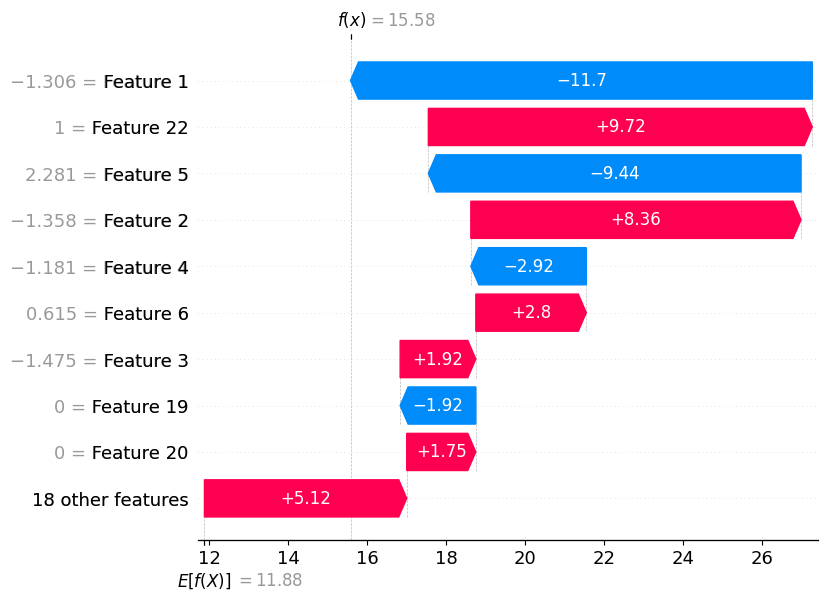

In [ ]:
#Step 6: Explain a single observation’s prediction (local explanation)
obs_idx = 0
shap.plots.waterfall(shap_values[obs_idx])


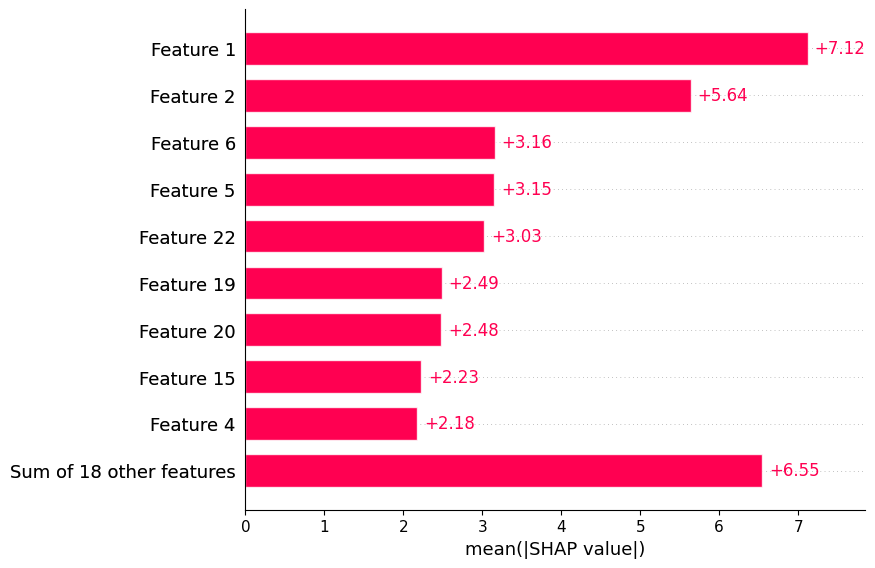

In [ ]:
#Step 7: Explain overall feature importance (global explanation)
shap.plots.bar(shap_values)


*(Answer here.)*

Which features to consider removing?

-The SHAP summary plot (from step 7 above) shows the mean absolute SHAP values for features, indicating overall feature importance.
-Features like Feature 1 and Feature 2 have the highest importance, so they should definitely be kept.
-Features ranked lower in importance, such as Feature 15, Feature 4, or any features grouped in "Sum of 18 other features," have relatively small contributions on average. These might be candidates for removal.
-The specific local explanation (from step 6 above) shows how different features impact one single prediction. Features with very low absolute SHAP values for most observations may be less relevant.

Why remove some features?
-Features with very low SHAP values contribute little to model predictions, so removing them can reduce model complexity, decrease training time, and improve interpretability without sacrificing much predictive power.
-Sometimes, less important features can introduce noise or lead to overfitting, so removing them could improve generalization.

How to test if the removed features enhance model performance?
-Feature removal and retraining:Remove the selected low-importance features from the dataset.

-Retrain the model using the reduced feature set.
Evaluate performance change:Use the same evaluation metric (e.g., RMSE, MAE) on validation or test data to compare the original model and the reduced-feature model.

If performance remains the same or improves, it confirms those features were not essential.

If performance degrades significantly, it means those features do contribute valuable information.

-Cross-validation:Perform cross-validation to check consistency of performance differences.

-Use statistical tests:If applicable, use paired statistical tests (e.g., paired t-test) on cross-validation scores to determine if performance changes are statistically significant.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.